# Prueba de Dunn (parte 2)

En la lección anterior aplicamos la prueba de Kruskal-Wallis a este problema:

> *Supongamos que como Científicos de Datos estamos evaluando el rendimiento de una API de un Modelo de Machine Learning desplegada en 3 servidores distintos: AWS, Azure y Google Cloud. Recolectamos datos por cada servidor y medimos en cada caso el tiempo de respuesta (en ms). **¿El tipo de servidor afecta el tiempo de respuesta de la API?***

Y encontramos que desde el punto de vista estadístico los tres servidores son diferentes en términos de los tiempos de respuesta.

Ahora la idea es usar la prueba de Dunn para determinar posibles diferencias entre pares de grupos.

## 1. Características de los datos

Carguemos el set de datos que usamos en la lección anterior:

In [1]:
import pandas as pd

RUTA = '/Users/miguel/Library/CloudStorage/GoogleDrive-miguel@codificandobits.com/My Drive/02-CODIFICANDOBITS.COM/04-Academia/01-Cursos/46-2026-04-EstadisticaInferencialNoParametrica/data/'

datos = pd.read_csv(RUTA + 'dataset_kruskal_wallis.csv')
datos

,A,B,C
0,17.4,44.1,28.9
1,19.1,48.6,25.1
2,13.7,47.3,33.3
3,21.2,47.5,24.4
4,20.4,47.4,28.0
...,...,...,...
395,16.4,41.2,34.3
396,17.9,49.9,25.4
397,15.4,45.4,25.8
398,14.7,40.1,25.8


## 2. Resultados de la prueba Kruskal-Wallis

Y recordemos el resultado obtenido con Kruskal-Wallis:

In [2]:
from pingouin import kruskal

# Llevar tabla a formato largo
datos_largo = datos.melt(var_name="servidor", value_name="tiempo")

# Y aplicar la prueba
resultados = kruskal(
    data = datos_largo,
    dv = 'tiempo', # Variable numérica
    between = 'servidor', # El factor
    )
resultados

,Source,ddof1,H,p-unc
Kruskal,servidor,2,1061.240678,3.585212e-231


Lo cual confirma que efectivamente existen diferencias entre los tres grupos.

Y veamos gráficamente las diferencias existentes entre los rangos de estos grupos.

Para ello:
1. Llevamos la tabla a formato largo
2. Calculamos los rangos
3. Y las sumas de los rangos
4. Y creamos un gráfico de barras

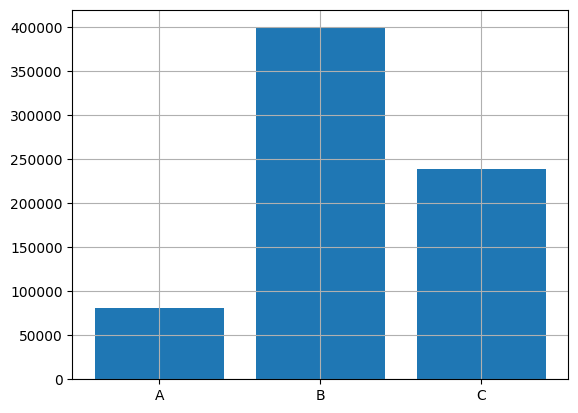

In [3]:
import matplotlib.pyplot as plt

# Calcular suma de rangos de cada grupo
datos_stack = datos.stack()                 # Datos en formato largo
rangos = datos_stack.rank(method='average')
sumas_rangos = rangos.groupby(level=1).sum()


# Gráfico
plt.bar(x = [1,2,3], height=sumas_rangos)
plt.xticks([1, 2, 3], ['A', 'B', 'C'])
plt.grid();

Observaciones: ¡al parecer entre pares de grupos existen grandes diferencias!

## 3. Prueba de Dunn (post-hoc)

Y veamos cómo aplicar la prueba usando la corrección de Bonferroni:

In [5]:
from scikit_posthocs import posthoc_dunn

resultados = posthoc_dunn(datos_largo,
                         group_col='servidor',
                         val_col='tiempo',
                         p_adjust='bonferroni')
resultados

,A,B,C
A,1.000000e+00,2.651303e-232,1.988548e-58
B,2.651303e-232,1.000000e+00,6.407293e-60
C,1.988548e-58,6.407293e-60,1.000000e+00


Todos los valores son prácticamente iguales a 0 lo cual nos indica que **entre pares de servidores todos los tiempos de respuesta son diferentes**.

Veamos lo que ocurre si aplicamos la corrección de Benjamini/Hochberg:

In [6]:
resultados = posthoc_dunn(datos_largo,
                         group_col='servidor',
                         val_col='tiempo',
                         p_adjust='fdr_bh')
resultados

,A,B,C
A,1.000000e+00,2.651303e-232,6.628495e-59
B,2.651303e-232,1.000000e+00,3.203647e-60
C,6.628495e-59,3.203647e-60,1.000000e+00


La conclusión es la misma del caso anterior: **entre pares de servidores todos los tiempos de respuesta son diferentes**.

Acá no hubo una diferencia entre las dos correcciones pero esto se debe a que de por sí los grupos tienen rangos (y por tanto tiempos de respuesta) muy diferentes los unos de los otros.

Si hubiese dos grupos relativamente "cercanos" es posible que una prueba hubiese arrojado diferencias significativas y otra no.

## 4. Una nota importante: no confiar ciegamente en los resultados de las pruebas

Como en todo proyecto de Ciencia de Datos, al final debemos siempre retornar al punto de inicio: **el problema de negocio**.

Por ejemplo, qué sucede si encontramos que A, B y C son diferentes entre sí pero:

- Los rangos (tiempos) en A <<<< B
- Los rangos (tiempos) en A son **ligeramente menores que C**
- Los rangos (tiempos) en C son <<< B

Es decir tenemos algo como esto:

A ||||||||||||||

B |||||||||||||||||||||||||||||||||||

C ||||||||||||||||

Las pruebas (Kruskal-Wallis y Dunn) nos indican que:

- Todos los grupos son diferentes
- Y entre pares de grupos hay diferencias

Pero el negocio debe tomar una decisión: **¿contrata el servidor A o el servidor C?**

¡Esta pregunta no la resuelve una prueba estadística!

En el comparativo anterior vemos que a pesar de que hay diferencias entre pares de grupos:
- B es el tipo de servidor más lento: ❌ lo descartamos porque realmente es mucho más lento que A y C
- C y A tienen tiempos de respuesta similares, siendo A el más rápido

¿Nos inclinamos por A o por C?

En este caso debemos considerar:
- ¿Cuánto cuesta contratar servicios con A o con C?
- ¿Qué costo tendría tener tiempos de respuesta ligeramente más lentos (C) o ligeramente menores (A)?

¡Es decir, la respuesta final **debe tener en cuenta el contexto del negocio** y no sólo el resultado de la prueba!